# Đánh giá mô hình trên Test Set
So sánh **Fast R-CNN** và **Faster R-CNN** trên tập test chưa thấy trong quá trình huấn luyện.

**Metrics:** Precision · Recall · F1-Score · Mean IoU · **mAP@0.5** · **mAP@0.5:0.95**

In [20]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'torchmetrics[detection]', '--quiet'], check=True)
print('torchmetrics ready')

torchmetrics ready


In [21]:
import os, random, pickle, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import OrderedDict
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models import ResNet50_Weights
from torchvision.ops import MultiScaleRoIAlign
from torchvision.models.detection.roi_heads import RoIHeads
from torchvision.models.detection.transform import GeneralizedRCNNTransform
from torchmetrics.detection import MeanAveragePrecision
warnings.filterwarnings('ignore')

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device  :', device)
print('PyTorch :', torch.__version__)
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))

Device  : cuda
PyTorch : 2.11.0+cu128
GPU     : NVIDIA GeForce RTX 5090


In [22]:
! pip install albumentations --quiet
print('Albumentations ready')

Albumentations ready


In [ ]:
BASE_DIR    = r'/workspace'
DATASET_DIR = os.path.join(BASE_DIR, 'dataset', 'dataset_coco_cropped')
TEST_IMG    = os.path.join(DATASET_DIR, 'test', 'images')
TEST_ANN    = os.path.join(DATASET_DIR, 'test', '_annotations.coco.json')

FASTER_RCNN_PTH    = os.path.join(BASE_DIR, 'faster_rcnn_v2_output', 'faster_rcnn_best.pth')
FAST_RCNN_PTH      = os.path.join(BASE_DIR, 'fast_rcnn_output',      'fast_rcnn_best.pth')
FAST_RCNN_SS_CACHE = os.path.join(DATASET_DIR, 'test_ss_proposals.pkl')

# Training history CSV — dùng cho biểu đồ so sánh quá trình huấn luyện
FASTER_RCNN_HIST = os.path.join(BASE_DIR, 'faster_rcnn_v2_output', 'training_history.csv')
FAST_RCNN_HIST   = os.path.join(BASE_DIR, 'fast_rcnn_output',      'training_history.csv')

NUM_CLASSES  = 3   # background(0) + helmet(1) + no_helmet(2)
CLASS_NAMES  = {1: 'helmet', 2: 'no_helmet'}
SCORE_THRESH = 0.5
IOU_THRESH   = 0.5
BATCH_SIZE   = 4
NUM_WORKERS  = 0

print('===== PATHS =====')
for name, p in [('TEST_IMG',         TEST_IMG),
                ('TEST_ANN',         TEST_ANN),
                ('FASTER_RCNN_PTH',  FASTER_RCNN_PTH),
                ('FAST_RCNN_PTH',    FAST_RCNN_PTH),
                ('SS_CACHE',         FAST_RCNN_SS_CACHE),
                ('FASTER_RCNN_HIST', FASTER_RCNN_HIST),
                ('FAST_RCNN_HIST',   FAST_RCNN_HIST)]:
    status = 'OK     ' if os.path.exists(p) else 'MISSING'
    print(f'  {status}  {name}: {p}')

## 1. Dataset — Test Set

In [24]:
class TestDataset(Dataset):
    """Dataset don gian cho test set — khong augmentation."""
    def __init__(self, img_dir, ann_file):
        self.img_dir = img_dir
        self.coco    = COCO(ann_file)
        self.ids     = list(self.coco.imgs.keys())
        self.transform = A.Compose([
            ToTensorV2(),
        ])

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        img_id   = self.ids[idx]
        img_info = self.coco.imgs[img_id]
        img      = np.array(Image.open(
            os.path.join(self.img_dir, img_info['file_name'])).convert('RGB'))
        H, W     = img.shape[:2]
        ann_ids  = self.coco.getAnnIds(imgIds=img_id)
        anns     = self.coco.loadAnns(ann_ids)
        boxes, labels = [], []
        for a in anns:
            x, y, w, h = [float(v) for v in a['bbox']]
            if w > 1 and h > 1:
                boxes.append([x, y, x+w, y+h])
                labels.append(int(a['category_id']))
        img_t = self.transform(image=img)['image'].float() / 255.0
        gt_boxes  = torch.tensor(boxes,  dtype=torch.float32) if boxes \
                    else torch.zeros((0,4), dtype=torch.float32)
        gt_labels = torch.tensor(labels, dtype=torch.int64) if labels \
                    else torch.zeros((0,), dtype=torch.int64)
        return img_t, {'boxes': gt_boxes, 'labels': gt_labels,
                        'image_id': torch.tensor([img_id])}

def collate_fn(batch): return tuple(zip(*batch))

test_dataset = TestDataset(TEST_IMG, TEST_ANN)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          collate_fn=collate_fn)
print(f'Test set: {len(test_dataset)} anh | {len(test_loader)} batches')

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Test set: 492 anh | 123 batches


## 2. Khởi tạo Model

In [25]:
# ── Faster R-CNN (ResNet-50 FPN V2) ──────────────────────────────────────
class TwoMLPHeadDropout(nn.Module):
    def __init__(self, in_channels, representation_size, dropout=0.2):
        super().__init__()
        self.fc6  = nn.Linear(in_channels, representation_size)
        self.fc7  = nn.Linear(representation_size, representation_size)
        self.drop = nn.Dropout(p=dropout)
    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = self.drop(F.relu(self.fc6(x)))
        x = self.drop(F.relu(self.fc7(x)))
        return x

def build_faster_rcnn(num_classes=3, dropout=0.1):
    model = fasterrcnn_resnet50_fpn_v2(
        weights=None,  # weights se duoc nan tu checkpoint
        trainable_backbone_layers=0,
        min_size=640, max_size=1024,
    )
    if dropout > 0:
        new_layers = []
        for layer in model.roi_heads.box_head.children():
            new_layers.append(layer)
            if isinstance(layer, nn.Linear):
                new_layers.append(nn.Dropout(p=dropout))
        model.roi_heads.box_head = nn.Sequential(*new_layers)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


# ── Fast R-CNN (ResNet-50 FPN) ─────────────────────────────────────────────
import torch.nn.functional as TF

class FastRCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.2):
        super().__init__()
        self.backbone = resnet_fpn_backbone(
            backbone_name='resnet50', weights=ResNet50_Weights.DEFAULT,
            trainable_layers=0)
        out_ch = self.backbone.out_channels
        self.transform = GeneralizedRCNNTransform(
            min_size=640, max_size=1024,
            image_mean=[0.485,0.456,0.406],
            image_std=[0.229,0.224,0.225])
        box_head = TwoMLPHeadDropout(
            in_channels=out_ch*7*7, representation_size=1024, dropout=dropout)
        self.roi_heads = RoIHeads(
            box_roi_pool=MultiScaleRoIAlign(
                featmap_names=['0','1','2','3'], output_size=7, sampling_ratio=2),
            box_head=box_head,
            box_predictor=FastRCNNPredictor(1024, num_classes),
            fg_iou_thresh=0.5, bg_iou_thresh=0.5,
            batch_size_per_image=512, positive_fraction=0.25,
            bbox_reg_weights=None,
            score_thresh=0.05, nms_thresh=0.5, detections_per_img=100)

    def forward(self, images, proposals_list, targets=None):
        orig_sizes = [(img.shape[-2], img.shape[-1]) for img in images]
        images_t, targets = self.transform(images, targets)
        scaled = []
        for props, orig, new in zip(proposals_list, orig_sizes, images_t.image_sizes):
            if props.shape[0] == 0: scaled.append(props); continue
            sh = new[0]/orig[0]; sw = new[1]/orig[1]
            s  = props.clone().float()
            s[:,0]*=sw; s[:,2]*=sw; s[:,1]*=sh; s[:,3]*=sh
            s[:,0].clamp_(0,new[1]); s[:,2].clamp_(0,new[1])
            s[:,1].clamp_(0,new[0]); s[:,3].clamp_(0,new[0])
            scaled.append(s)
        features = self.backbone(images_t.tensors)
        if isinstance(features, torch.Tensor):
            features = OrderedDict([('0', features)])
        detections, _ = self.roi_heads(
            features, scaled, images_t.image_sizes, None)
        return self.transform.postprocess(
            detections, images_t.image_sizes, orig_sizes)

print('Model builders defined OK')

Model builders defined OK


## 3. Hàm đánh giá

In [26]:
def _box_iou_single(boxA, boxB):
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0.0, xB-xA) * max(0.0, yB-yA)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0


def evaluate_full(model, loader, device,
                  iou_thresh=0.5, score_thresh=0.5,
                  proposals_dict=None):
    """
    Tinh day du: Precision, Recall, F1, Mean IoU, mAP@0.5, mAP@0.5:0.95.
    proposals_dict: chi truyen vao khi dung Fast R-CNN.
    """
    model.eval()
    tp = fp = fn = 0
    iou_sum = 0.0
    map_metric = MeanAveragePrecision(
        iou_thresholds=[0.5],
        iou_type='bbox',
        class_metrics=True,
    )
    map_metric_full = MeanAveragePrecision(
        iou_thresholds=[round(x,2) for x in
                         [0.5+0.05*i for i in range(10)]],
        iou_type='bbox',
    )

    with torch.no_grad():
        for batch in loader:
            if proposals_dict is not None:
                images, targets = batch
                images = [img.to(device) for img in images]
                props  = []
                for t in targets:
                    img_id = t['image_id'].item()
                    raw = proposals_dict.get(img_id, [])
                    p = torch.tensor(raw[:2000], dtype=torch.float32).to(device) \
                        if len(raw) > 0 else \
                        torch.zeros((1,4), dtype=torch.float32).to(device)
                    props.append(p)
                outputs = model(images, props)
            else:
                images, targets = batch
                images  = [img.to(device) for img in images]
                outputs = model(images)

            # Chuan bi cho torchmetrics
            preds_tm, tgts_tm = [], []
            for target, out in zip(targets, outputs):
                gt_boxes    = target['boxes'].cpu().numpy()
                gt_labels   = target['labels'].cpu()
                pred_boxes  = out['boxes'].cpu().numpy()
                pred_scores = out['scores'].cpu().numpy()
                pred_labels = out['labels'].cpu()

                keep        = pred_scores >= score_thresh
                pred_boxes_f  = pred_boxes[keep]
                pred_scores_f = pred_scores[keep]
                pred_labels_f = pred_labels[keep]

                # torchmetrics format
                preds_tm.append({
                    'boxes':  torch.tensor(pred_boxes_f,  dtype=torch.float32),
                    'scores': torch.tensor(pred_scores_f, dtype=torch.float32),
                    'labels': pred_labels_f.long(),
                })
                tgts_tm.append({
                    'boxes':  target['boxes'].float(),
                    'labels': gt_labels.long(),
                })
                map_metric.update(preds_tm[-1:], tgts_tm[-1:])
                map_metric_full.update(preds_tm[-1:], tgts_tm[-1:])

                # P/R/F1/IoU thu cong
                order = pred_scores_f.argsort()[::-1]
                pred_boxes_f = pred_boxes_f[order]
                gt_matched   = [False] * len(gt_boxes)
                tp_img = 0
                for pb in pred_boxes_f:
                    best_iou = iou_thresh - 1e-9; best_gi = -1
                    for gi, gb in enumerate(gt_boxes):
                        if gt_matched[gi]: continue
                        iou = _box_iou_single(pb, gb)
                        if iou > best_iou: best_iou = iou; best_gi = gi
                    if best_gi >= 0:
                        gt_matched[best_gi] = True
                        tp_img  += 1
                        iou_sum += best_iou
                fp += len(pred_boxes_f) - tp_img
                fn += sum(1 for m in gt_matched if not m)
                tp += tp_img

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0
    mean_iou  = iou_sum / tp if tp > 0 else 0.0

    map_res      = map_metric.compute()
    map_res_full = map_metric_full.compute()
    map50        = map_res['map_50'].item()
    map50_95     = map_res_full['map'].item()

    # Per-class AP
    per_class = {}
    if 'map_per_class' in map_res:
        for i, ap in enumerate(map_res['map_per_class']):
            cls_id = i + 1
            per_class[CLASS_NAMES.get(cls_id, f'cls{cls_id}')] = ap.item()

    return {
        'precision': precision, 'recall': recall,
        'f1': f1,               'mean_iou': mean_iou,
        'map50': map50,         'map50_95': map50_95,
        'per_class_ap': per_class,
        'tp': tp, 'fp': fp, 'fn': fn,
    }

print('evaluate_full defined OK')

evaluate_full defined OK


## 4. Đánh giá Faster R-CNN trên Test Set

In [27]:
faster_results = None

if os.path.exists(FASTER_RCNN_PTH):
    print('Loading Faster R-CNN...')
    faster_model = build_faster_rcnn(num_classes=NUM_CLASSES, dropout=0.1).to(device)
    faster_model.load_state_dict(
        torch.load(FASTER_RCNN_PTH, map_location=device))
    faster_model.eval()
    print('Model loaded! Dang danh gia...')

    faster_results = evaluate_full(
        faster_model, test_loader, device,
        iou_thresh=IOU_THRESH, score_thresh=SCORE_THRESH,
    )

    print('\n===== KET QUA FASTER R-CNN TREN TEST SET =====')
    print(f"  Precision  : {faster_results['precision']:.4f}")
    print(f"  Recall     : {faster_results['recall']:.4f}")
    print(f"  F1-Score   : {faster_results['f1']:.4f}")
    print(f"  Mean IoU   : {faster_results['mean_iou']:.4f}")
    print(f"  mAP@0.5    : {faster_results['map50']:.4f}")
    print(f"  mAP@0.5:0.95: {faster_results['map50_95']:.4f}")
    print('  Per-class AP@0.5:')
    for cls, ap in faster_results['per_class_ap'].items():
        print(f'    {cls:20s}: {ap:.4f}')
    del faster_model; torch.cuda.empty_cache()
else:
    print(f'KHONG TIM THAY: {FASTER_RCNN_PTH}')

Loading Faster R-CNN...
Model loaded! Dang danh gia...

===== KET QUA FASTER R-CNN TREN TEST SET =====
  Precision  : 0.8103
  Recall     : 0.9216
  F1-Score   : 0.8624
  Mean IoU   : 0.8210
  mAP@0.5    : 0.8697
  mAP@0.5:0.95: 0.5537
  Per-class AP@0.5:
    helmet              : 0.8650
    no_helmet           : 0.8744


## 5. Đánh giá Fast R-CNN trên Test Set

## 5b. Sinh Selective Search proposals cho Test Set (Fast R-CNN)

Chỉ chạy **một lần** — kết quả được cache vào `test_ss_proposals.pkl`.

In [28]:
# Sinh SS proposals cho test set (neu chua co)
if not os.path.exists(FAST_RCNN_SS_CACHE):
    print('Chua co test_ss_proposals.pkl — dang sinh...')
    from pycocotools.coco import COCO as _COCO
    _coco  = _COCO(TEST_ANN)
    _ids   = list(_coco.imgs.keys())
    _ss    = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    _cache = {}
    _MAX   = 2000
    for _i, _img_id in enumerate(_ids):
        _info    = _coco.imgs[_img_id]
        _imgpath = os.path.join(TEST_IMG, _info['file_name'])
        _bgr     = cv2.imread(_imgpath)
        if _bgr is None:
            _cache[_img_id] = np.zeros((0,4), dtype=np.float32)
            continue
        _ss.setBaseImage(_bgr)
        _ss.switchToSelectiveSearchFast()
        _rects = _ss.process()[:_MAX]
        if len(_rects):
            _r = np.array(_rects, dtype=np.float32)
            _cache[_img_id] = np.stack(
                [_r[:,0], _r[:,1], _r[:,0]+_r[:,2], _r[:,1]+_r[:,3]], axis=1)
        else:
            _cache[_img_id] = np.zeros((0,4), dtype=np.float32)
        if (_i+1) % 50 == 0:
            print(f'  {_i+1}/{len(_ids)} anh xong...')
            with open(FAST_RCNN_SS_CACHE, 'wb') as _f:
                pickle.dump(_cache, _f)
    with open(FAST_RCNN_SS_CACHE, 'wb') as _f:
        pickle.dump(_cache, _f)
    print(f'Da luu: {FAST_RCNN_SS_CACHE}')
else:
    print(f'Da co SS cache: {FAST_RCNN_SS_CACHE}')


Da co SS cache: /workspace/dataset/dataset_coco_cropped/test_ss_proposals.pkl


In [29]:
fast_results = None

if os.path.exists(FAST_RCNN_PTH):
    # Pre-compute SS proposals cho test set (neu chua co)
    if os.path.exists(FAST_RCNN_SS_CACHE):
        with open(FAST_RCNN_SS_CACHE, 'rb') as f:
            test_proposals = pickle.load(f)
        print(f'SS cache loaded: {FAST_RCNN_SS_CACHE}')
    else:
        print('Chua co SS cache cho test set.')
        print('Chay cell nay truoc:')
        print('  from Fast_RCNN.Train_FastRCNN_Optuna import precompute_ss_proposals')
        print('  test_proposals = precompute_ss_proposals(TEST_IMG, TEST_ANN, FAST_RCNN_SS_CACHE)')
        test_proposals = None

    if test_proposals is not None:
        print('Loading Fast R-CNN...')
        fast_model = FastRCNN(num_classes=NUM_CLASSES, dropout=0.2).to(device)
        fast_model.load_state_dict(
            torch.load(FAST_RCNN_PTH, map_location=device))
        fast_model.eval()
        print('Model loaded! Dang danh gia...')

        fast_results = evaluate_full(
            fast_model, test_loader, device,
            iou_thresh=IOU_THRESH, score_thresh=SCORE_THRESH,
            proposals_dict=test_proposals,
        )

        print('\n===== KET QUA FAST R-CNN TREN TEST SET =====')
        print(f"  Precision  : {fast_results['precision']:.4f}")
        print(f"  Recall     : {fast_results['recall']:.4f}")
        print(f"  F1-Score   : {fast_results['f1']:.4f}")
        print(f"  Mean IoU   : {fast_results['mean_iou']:.4f}")
        print(f"  mAP@0.5    : {fast_results['map50']:.4f}")
        print(f"  mAP@0.5:0.95: {fast_results['map50_95']:.4f}")
        print('  Per-class AP@0.5:')
        for cls, ap in fast_results['per_class_ap'].items():
            print(f'    {cls:20s}: {ap:.4f}')
        del fast_model; torch.cuda.empty_cache()
else:
    print(f'Chua co model Fast R-CNN: {FAST_RCNN_PTH}')
    print('Train Fast R-CNN truoc roi quay lai chay cell nay.')

SS cache loaded: /workspace/dataset/dataset_coco_cropped/test_ss_proposals.pkl
Loading Fast R-CNN...
Model loaded! Dang danh gia...

===== KET QUA FAST R-CNN TREN TEST SET =====
  Precision  : 0.8195
  Recall     : 0.7958
  F1-Score   : 0.8075
  Mean IoU   : 0.8279
  mAP@0.5    : 0.7428
  mAP@0.5:0.95: 0.4856
  Per-class AP@0.5:
    helmet              : 0.7327
    no_helmet           : 0.7530


## 6. Bảng so sánh tổng hợp

In [30]:
rows = []
if faster_results:
    rows.append({'Model': 'Faster R-CNN (ResNet-50 FPN V2)',
                 **{k: round(v,4) for k,v in faster_results.items()
                    if k not in ['per_class_ap','tp','fp','fn']}})
if fast_results:
    rows.append({'Model': 'Fast R-CNN (ResNet-50 FPN)',
                 **{k: round(v,4) for k,v in fast_results.items()
                    if k not in ['per_class_ap','tp','fp','fn']}})

if rows:
    df = pd.DataFrame(rows).set_index('Model')
    df.columns = ['Precision','Recall','F1','Mean IoU','mAP@0.5','mAP@0.5:0.95']
    print('\n===== SO SANH 2 MO HINH TREN TEST SET =====')
    print(df.to_string())
    df.to_csv(os.path.join(BASE_DIR, 'test_evaluation_results.csv'))
    print('\nDa luu: test_evaluation_results.csv')
else:
    print('Chua co ket qua nao. Chay cac cell tren truoc.')


===== SO SANH 2 MO HINH TREN TEST SET =====
                                 Precision  Recall      F1  Mean IoU  mAP@0.5  mAP@0.5:0.95
Model                                                                                      
Faster R-CNN (ResNet-50 FPN V2)     0.8103  0.9216  0.8624    0.8210   0.8697        0.5537
Fast R-CNN (ResNet-50 FPN)          0.8195  0.7958  0.8075    0.8279   0.7428        0.4856

Da luu: test_evaluation_results.csv


## 6b. So sánh đường cong huấn luyện (Loss & Metrics)

Load `training_history.csv` từ cả hai mô hình và vẽ 2 biểu đồ so sánh:
- **Hình 1 — Loss:** Train Loss và Val Loss song song theo epoch
- **Hình 2 — Metrics:** F1-Score, Precision, Recall theo epoch với điểm best epoch được đánh dấu

> ⚠️ Val Loss của hai mô hình **không so sánh trực tiếp** được vì Fast R-CNN có 2 loss terms còn Faster R-CNN có 4 (thêm RPN). Chỉ so sánh xu hướng hội tụ.

In [ ]:
import matplotlib.ticker as ticker

# ── Load training history CSVs ────────────────────────────────────────────────
df_faster = pd.read_csv(FASTER_RCNN_HIST) if os.path.exists(FASTER_RCNN_HIST) else None
df_fast   = pd.read_csv(FAST_RCNN_HIST)   if os.path.exists(FAST_RCNN_HIST)   else None

if df_faster is None and df_fast is None:
    print('Không tìm thấy training_history.csv — bỏ qua phần này.')
else:
    if df_faster is not None: print(f'Faster R-CNN history: {len(df_faster)} epochs')
    if df_fast   is not None: print(f'Fast R-CNN   history: {len(df_fast)} epochs')

    C_FASTER = '#2196F3'    # xanh dương — Faster R-CNN
    C_FAST   = '#FF5722'    # cam đỏ    — Fast R-CNN

    # ── Hình 1: So sánh Loss ──────────────────────────────────────────────────
    fig1, axes1 = plt.subplots(1, 2, figsize=(16, 5))
    fig1.suptitle('So sánh Loss trong quá trình huấn luyện',
                  fontsize=14, fontweight='bold')

    for ax, col, title_lbl in zip(axes1,
                                   ['train_loss', 'val_loss'],
                                   ['Train Loss', 'Validation Loss']):
        for df, name, c, m in [(df_faster, 'Faster R-CNN', C_FASTER, 'o'),
                                (df_fast,   'Fast R-CNN',   C_FAST,   's')]:
            if df is None or col not in df.columns: continue
            ax.plot(df['epoch'], df[col], color=c, lw=2,
                    marker=m, ms=4, markevery=3, label=name)
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.set_title(title_lbl, fontweight='bold')
        ax.legend(); ax.grid(True, ls='--', alpha=0.4)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

    # Chú thích khác biệt thang đo ở Val Loss
    axes1[1].text(0.98, 0.96,
        'Fast R-CNN: 2 loss terms (cls + bbox reg)\n'
        'Faster R-CNN: 4 loss terms (+ RPN ×2)\n'
        '→ Giá trị tuyệt đối không thể so sánh trực tiếp\n'
        '   Chỉ so sánh xu hướng theo epoch',
        transform=axes1[1].transAxes, ha='right', va='top', fontsize=8.5,
        style='italic', color='#555',
        bbox=dict(boxstyle='round,pad=0.4', fc='#FFFFF0', alpha=0.9))

    plt.tight_layout()
    p1 = os.path.join(BASE_DIR, 'training_loss_comparison.png')
    plt.savefig(p1, dpi=150, bbox_inches='tight')
    plt.show(); print(f'Đã lưu: training_loss_comparison.png')

    # ── Hình 2: So sánh Metrics (F1 · Precision · Recall) ────────────────────
    fig2, axes2 = plt.subplots(1, 3, figsize=(20, 5))
    fig2.suptitle('So sánh Metrics trên tập Validation trong quá trình huấn luyện',
                  fontsize=14, fontweight='bold')

    for ax, col, ylabel in zip(axes2,
                                ['f1',       'precision', 'recall'],
                                ['F1-Score', 'Precision', 'Recall']):
        for df, name, c, m in [(df_faster, 'Faster R-CNN', C_FASTER, 'o'),
                                (df_fast,   'Fast R-CNN',   C_FAST,   's')]:
            if df is None or col not in df.columns: continue

            ax.plot(df['epoch'], df[col], color=c, lw=2,
                    marker=m, ms=4, markevery=3, label=name)

            # Đánh dấu best epoch (theo F1-Score)
            best_idx = df['f1'].idxmax()
            best_ep  = df.loc[best_idx, 'epoch']
            best_val = df.loc[best_idx, col]
            ax.axvline(best_ep, color=c, ls=':', lw=1.5, alpha=0.6)
            ax.scatter([best_ep], [best_val], color=c, s=90, zorder=6,
                       edgecolors='white', linewidths=1.5)
            ax.annotate(f'{best_val:.3f}',
                        xy=(best_ep, best_val),
                        xytext=(6, 5), textcoords='offset points',
                        fontsize=9, color=c, fontweight='bold')

        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_title(ylabel, fontweight='bold')
        ax.set_ylim(0.0, 1.06)
        ax.legend(); ax.grid(True, ls='--', alpha=0.4)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

    plt.tight_layout()
    p2 = os.path.join(BASE_DIR, 'training_metrics_comparison.png')
    plt.savefig(p2, dpi=150, bbox_inches='tight')
    plt.show(); print(f'Đã lưu: training_metrics_comparison.png')

## 7. Biểu đồ so sánh

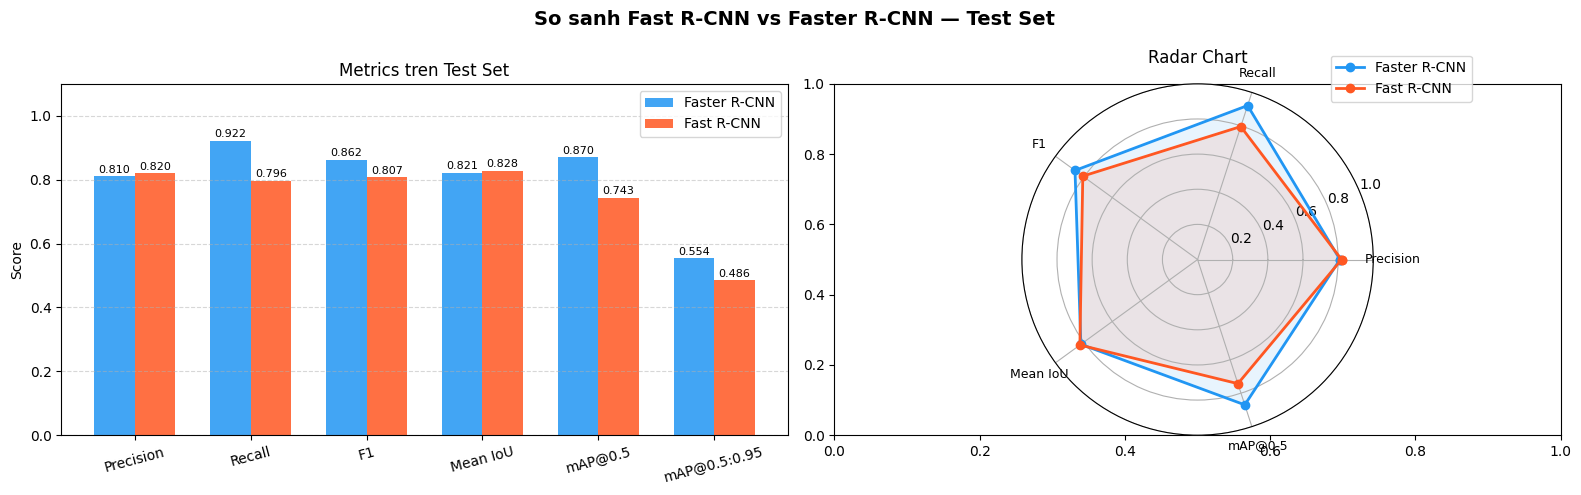

Da luu bieu do: /workspace/test_comparison.png


In [31]:
if rows:
    metrics = ['Precision','Recall','F1','Mean IoU','mAP@0.5','mAP@0.5:0.95']
    n_models = len(df)
    x = np.arange(len(metrics))
    width = 0.35
    colors = ['#2196F3', '#FF5722']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('So sanh Fast R-CNN vs Faster R-CNN — Test Set',
                 fontsize=14, fontweight='bold')

    # Bar chart
    ax = axes[0]
    for i, (model_name, row) in enumerate(df.iterrows()):
        offset = (i - n_models/2 + 0.5) * width
        bars = ax.bar(x + offset, row[metrics], width,
                      label=model_name.split('(')[0].strip(),
                      color=colors[i], alpha=0.85)
        for bar, val in zip(bars, row[metrics]):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(metrics, rotation=15)
    ax.set_ylabel('Score'); ax.set_ylim(0, 1.1)
    ax.set_title('Metrics tren Test Set'); ax.legend()
    ax.grid(axis='y', ls='--', alpha=0.5)

    # Radar chart
    ax2 = axes[1]
    use_metrics = ['Precision','Recall','F1','Mean IoU','mAP@0.5']
    angles = np.linspace(0, 2*np.pi, len(use_metrics), endpoint=False).tolist()
    angles += angles[:1]
    ax2 = fig.add_subplot(1, 2, 2, polar=True)
    for i, (model_name, row) in enumerate(df.iterrows()):
        vals = [row[m] for m in use_metrics] + [row[use_metrics[0]]]
        ax2.plot(angles, vals, 'o-', lw=2, color=colors[i],
                 label=model_name.split('(')[0].strip())
        ax2.fill(angles, vals, alpha=0.1, color=colors[i])
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(use_metrics, fontsize=9)
    ax2.set_ylim(0, 1)
    ax2.set_title('Radar Chart', pad=15)
    ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    save_path = os.path.join(BASE_DIR, 'test_comparison.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Da luu bieu do: {save_path}')
else:
    print('Chua co du lieu de ve bieu do.')

## 8. AP theo từng class

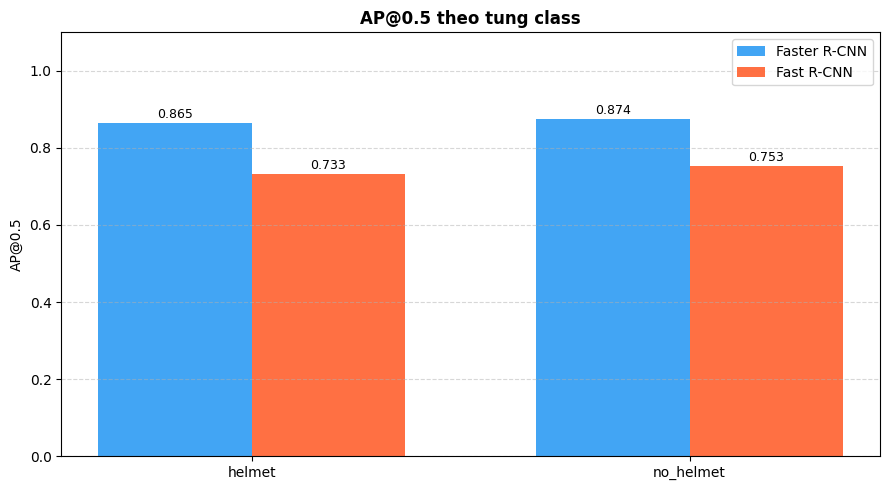

In [32]:
if faster_results and faster_results['per_class_ap']:
    cls_data = {}
    if faster_results:
        cls_data['Faster R-CNN'] = faster_results['per_class_ap']
    if fast_results and fast_results.get('per_class_ap'):
        cls_data['Fast R-CNN'] = fast_results['per_class_ap']

    class_names = list(list(cls_data.values())[0].keys())
    x = np.arange(len(class_names))
    width = 0.35
    colors = ['#2196F3', '#FF5722']

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (model_name, aps) in enumerate(cls_data.items()):
        offset = (i - len(cls_data)/2 + 0.5) * width
        vals = [aps.get(c, 0) for c in class_names]
        bars = ax.bar(x + offset, vals, width,
                      label=model_name, color=colors[i], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(class_names)
    ax.set_ylabel('AP@0.5'); ax.set_ylim(0, 1.1)
    ax.set_title('AP@0.5 theo tung class', fontweight='bold')
    ax.legend(); ax.grid(axis='y', ls='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'test_per_class_ap.png'), dpi=150)
    plt.show()
else:
    print('Chua co du lieu per-class.')

## 8b. Thời gian Inference (FPS)

Do FPS — Faster R-CNN...
  Faster R-CNN : 27.6 +/- 6.6 ms/anh  ->  36.2 FPS
Do FPS — Fast R-CNN...
  Fast R-CNN   : 21.8 +/- 6.9 ms/anh  ->  45.8 FPS

Model                         ms/image      std      FPS
--------------------------------------------------------
Faster R-CNN                    27.6ms    6.6ms    36.2
Fast R-CNN                      21.8ms    6.9ms    45.8


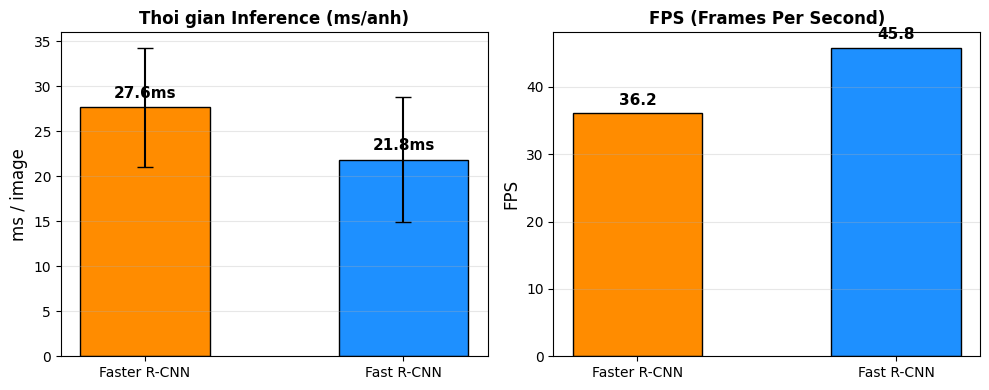

Da luu: inference_time_fps.png


In [35]:
def measure_fps(model, loader, device, model_type='faster',
                proposals_dict=None, n_warmup=5, n_measure=50):
    """
    Do thoi gian inference trung binh (ms/anh) va FPS.
    n_warmup : so batch GPU warm-up (bo qua khi tinh gio)
    n_measure: so batch tinh trung binh
    """
    model.eval()
    times    = []
    iter_all = iter(loader)

    with torch.no_grad():
        # --- Warm-up ---
        for _ in range(min(n_warmup, len(loader))):
            batch = next(iter_all)
            imgs, tgts = batch
            imgs = [img.to(device) for img in imgs]
            if model_type == 'fast':
                ps = []
                for t in tgts:
                    raw = proposals_dict.get(t['image_id'].item(), [])
                    p   = torch.tensor(raw[:2000], dtype=torch.float32).to(device) \
                          if len(raw) else torch.zeros((1,4), dtype=torch.float32).to(device)
                    ps.append(p)
                model(imgs, ps)
            else:
                model(imgs)
        if device.type == 'cuda':
            torch.cuda.synchronize()

        # --- Measurement ---
        cnt = 0
        for batch in loader:
            if cnt >= n_measure:
                break
            imgs, tgts = batch
            imgs  = [img.to(device) for img in imgs]
            n_img = len(imgs)
            if model_type == 'fast':
                ps = []
                for t in tgts:
                    raw = proposals_dict.get(t['image_id'].item(), [])
                    p   = torch.tensor(raw[:2000], dtype=torch.float32).to(device) \
                          if len(raw) else torch.zeros((1,4), dtype=torch.float32).to(device)
                    ps.append(p)
                if device.type == 'cuda': torch.cuda.synchronize()
                t0 = time.perf_counter()
                model(imgs, ps)
                if device.type == 'cuda': torch.cuda.synchronize()
            else:
                if device.type == 'cuda': torch.cuda.synchronize()
                t0 = time.perf_counter()
                model(imgs)
                if device.type == 'cuda': torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) / n_img)
            cnt += 1

    mean_ms = float(np.mean(times)) * 1000
    std_ms  = float(np.std(times))  * 1000
    fps     = 1000.0 / mean_ms
    return mean_ms, std_ms, fps


import time
fps_results = {}

# Faster R-CNN
if os.path.exists(FASTER_RCNN_PTH):
    print('Do FPS — Faster R-CNN...')
    _m = build_faster_rcnn(num_classes=NUM_CLASSES, dropout=0.1).to(device)
    _m.load_state_dict(torch.load(FASTER_RCNN_PTH, map_location=device))
    ms, std, fps = measure_fps(_m, test_loader, device, model_type='faster')
    fps_results['Faster R-CNN'] = {'ms': ms, 'std': std, 'fps': fps}
    print(f'  Faster R-CNN : {ms:.1f} +/- {std:.1f} ms/anh  ->  {fps:.1f} FPS')
    del _m; torch.cuda.empty_cache()

# Fast R-CNN
if os.path.exists(FAST_RCNN_PTH) and os.path.exists(FAST_RCNN_SS_CACHE):
    print('Do FPS — Fast R-CNN...')
    with open(FAST_RCNN_SS_CACHE, 'rb') as _f:
        _props = pickle.load(_f)
    _m2 = FastRCNN(num_classes=NUM_CLASSES, dropout=0.2).to(device)
    _m2.load_state_dict(torch.load(FAST_RCNN_PTH, map_location=device))
    ms2, std2, fps2 = measure_fps(_m2, test_loader, device,
                                   model_type='fast', proposals_dict=_props)
    fps_results['Fast R-CNN'] = {'ms': ms2, 'std': std2, 'fps': fps2}
    print(f'  Fast R-CNN   : {ms2:.1f} +/- {std2:.1f} ms/anh  ->  {fps2:.1f} FPS')
    del _m2; torch.cuda.empty_cache()

# In bang
print()
print(f'{"Model":<25} {"ms/image":>12} {"std":>8} {"FPS":>8}')
print('-' * 56)
for name, v in fps_results.items():
    print(f'{name:<25} {v["ms"]:>10.1f}ms {v["std"]:>6.1f}ms {v["fps"]:>7.1f}')

# Bar chart
if fps_results:
    names    = list(fps_results.keys())
    ms_vals  = [fps_results[n]['ms']  for n in names]
    fps_vals = [fps_results[n]['fps'] for n in names]
    std_vals = [fps_results[n]['std'] for n in names]
    bar_clr  = ['#FF8C00', '#1E90FF']

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].bar(names, ms_vals, yerr=std_vals, capsize=6,
                color=bar_clr, edgecolor='black', width=0.5)
    axes[0].set_ylabel('ms / image', fontsize=12)
    axes[0].set_title('Thoi gian Inference (ms/anh)', fontsize=12, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(ms_vals):
        axes[0].text(i, v + max(std_vals)*0.15,
                     f'{v:.1f}ms', ha='center', fontsize=11, fontweight='bold')

    axes[1].bar(names, fps_vals, color=bar_clr, edgecolor='black', width=0.5)
    axes[1].set_ylabel('FPS', fontsize=12)
    axes[1].set_title('FPS (Frames Per Second)', fontsize=12, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(fps_vals):
        axes[1].text(i, v * 1.03, f'{v:.1f}',
                     ha='center', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'inference_time_fps.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Da luu: inference_time_fps.png')


## 8c. Confusion Matrix

Tinh Confusion Matrix — Faster R-CNN...
Faster R-CNN CM:
[[  0  92  95]
 [ 48 463  18]
 [ 20  18 300]]


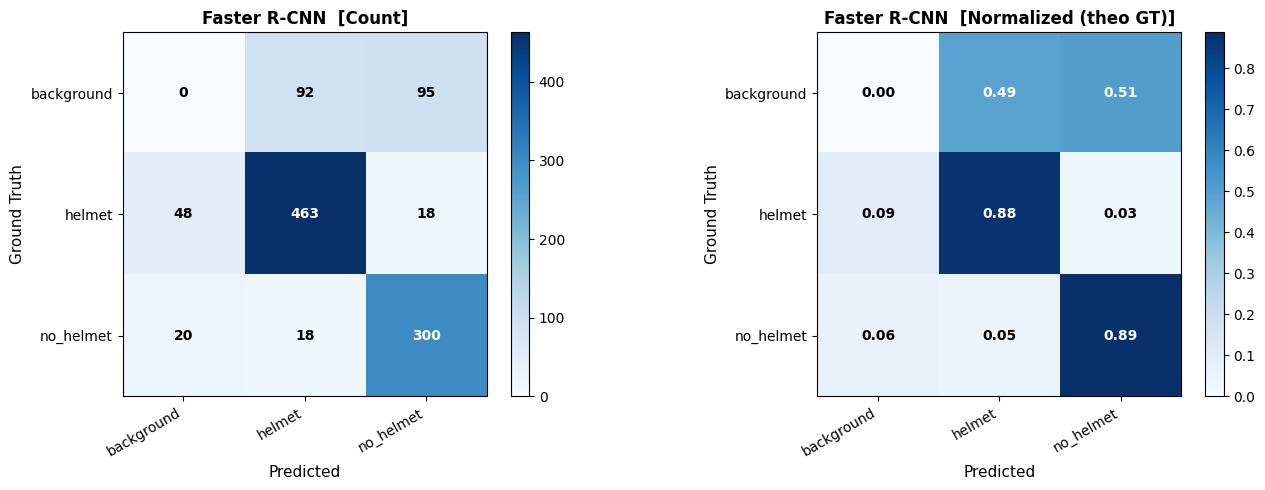

Da luu: confusion_matrix_faster_rcnn.png
Tinh Confusion Matrix — Fast R-CNN...
Fast R-CNN CM:
[[  0  68  84]
 [120 398  11]
 [ 57  18 263]]


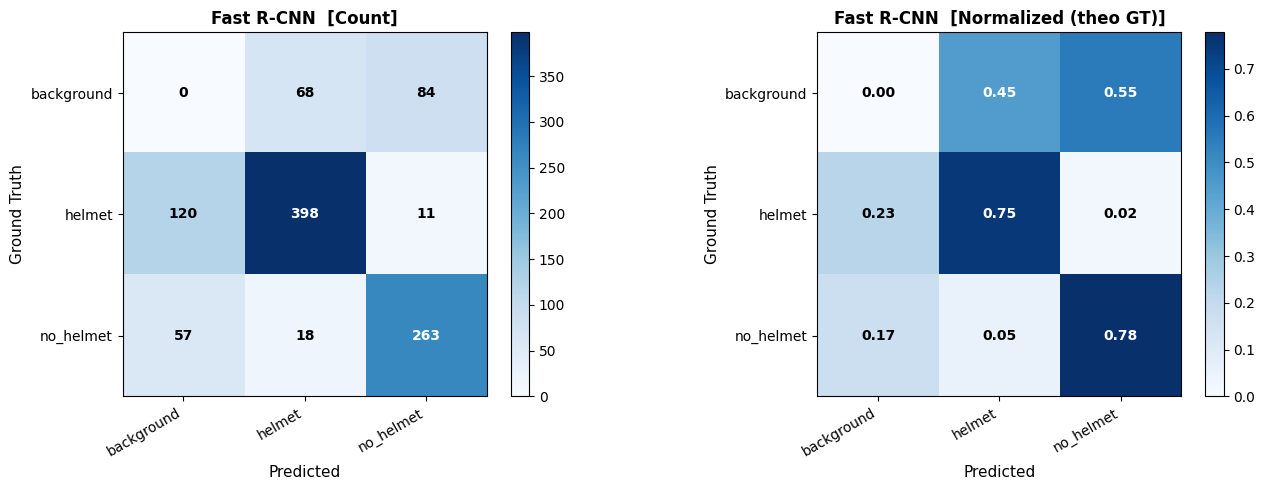

Da luu: confusion_matrix_fast_rcnn.png


In [36]:
def compute_confusion_matrix(model, loader, device, n_fg_classes,
                             model_type='faster', proposals_dict=None,
                             iou_thresh=0.5, score_thresh=0.5):
    """
    Xay dung confusion matrix cho object detection.
    CM shape: (n_fg_classes+1) x (n_fg_classes+1)
    Index 0 = Background:
      - Hang GT=cls,  Cot Pred=0   : bo sot (FN)
      - Hang GT=0,    Cot Pred=cls : phat hien nham (FP)
      - Hang GT=cls1, Cot Pred=cls2: nhan sai class
    """
    CM = np.zeros((n_fg_classes + 1, n_fg_classes + 1), dtype=int)
    model.eval()

    with torch.no_grad():
        for batch in loader:
            imgs, tgts = batch
            imgs = [img.to(device) for img in imgs]

            if model_type == 'fast':
                ps = []
                for t in tgts:
                    raw = proposals_dict.get(t['image_id'].item(), [])
                    p   = torch.tensor(raw[:2000], dtype=torch.float32).to(device) \
                          if len(raw) else torch.zeros((1,4), dtype=torch.float32).to(device)
                    ps.append(p)
                outputs = model(imgs, ps)
            else:
                outputs = model(imgs)

            for target, out in zip(tgts, outputs):
                gt_boxes  = target['boxes'].numpy()
                gt_labels = target['labels'].numpy()
                pb        = out['boxes'].cpu().numpy()
                ps_score  = out['scores'].cpu().numpy()
                pl        = out['labels'].cpu().numpy()

                keep = ps_score >= score_thresh
                pb   = pb[keep]; pl = pl[keep]; ps_score = ps_score[keep]
                order = ps_score.argsort()[::-1]
                pb = pb[order]; pl = pl[order]

                gt_matched = [False] * len(gt_boxes)

                for box, lbl in zip(pb, pl):
                    best_iou, best_gi = iou_thresh - 1e-9, -1
                    for gi, gb in enumerate(gt_boxes):
                        if gt_matched[gi]: continue
                        iou = _box_iou_single(box, gb)
                        if iou > best_iou:
                            best_iou = iou; best_gi = gi
                    if best_gi >= 0:
                        gt_matched[best_gi] = True
                        CM[int(gt_labels[best_gi])][int(lbl)] += 1
                    else:
                        # FP: GT=background(0), Pred=lbl
                        CM[0][int(lbl)] += 1

                for gi, matched in enumerate(gt_matched):
                    if not matched:
                        # FN: GT=label, Pred=background(0)
                        CM[int(gt_labels[gi])][0] += 1
    return CM


def plot_confusion_matrix(CM, class_names, title, save_name):
    labels = ['background'] + list(class_names.values())
    N = len(labels)

    CM_norm = CM.astype(float)
    row_sum = CM_norm.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1
    CM_norm = CM_norm / row_sum

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, fmt, sub in zip(
            axes,
            [CM,     CM_norm],
            ['d',    '.2f'],
            ['Count', 'Normalized (theo GT)']):
        im = ax.imshow(data, cmap='Blues', vmin=0)
        ax.set_xticks(range(N))
        ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)
        ax.set_yticks(range(N))
        ax.set_yticklabels(labels, fontsize=10)
        ax.set_xlabel('Predicted', fontsize=11)
        ax.set_ylabel('Ground Truth', fontsize=11)
        ax.set_title(f'{title}  [{sub}]', fontsize=12, fontweight='bold')
        thresh = data.max() / 2.0
        for i in range(N):
            for j in range(N):
                v     = data[i, j]
                color = 'white' if v > thresh else 'black'
                ax.text(j, i, f'{v:{fmt}}', ha='center', va='center',
                        fontsize=10, color=color, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, save_name), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Da luu: {save_name}')


N_FG = NUM_CLASSES - 1  # 2 foreground classes (helmet, no_helmet)

# Faster R-CNN
if os.path.exists(FASTER_RCNN_PTH):
    print('Tinh Confusion Matrix — Faster R-CNN...')
    _m = build_faster_rcnn(num_classes=NUM_CLASSES, dropout=0.1).to(device)
    _m.load_state_dict(torch.load(FASTER_RCNN_PTH, map_location=device))
    CM_faster = compute_confusion_matrix(
        _m, test_loader, device, n_fg_classes=N_FG,
        model_type='faster', iou_thresh=IOU_THRESH, score_thresh=SCORE_THRESH)
    del _m; torch.cuda.empty_cache()
    print('Faster R-CNN CM:'); print(CM_faster)
    plot_confusion_matrix(CM_faster, CLASS_NAMES,
                          title='Faster R-CNN',
                          save_name='confusion_matrix_faster_rcnn.png')

# Fast R-CNN
if os.path.exists(FAST_RCNN_PTH) and os.path.exists(FAST_RCNN_SS_CACHE):
    print('Tinh Confusion Matrix — Fast R-CNN...')
    with open(FAST_RCNN_SS_CACHE, 'rb') as _f:
        _props = pickle.load(_f)
    _m2 = FastRCNN(num_classes=NUM_CLASSES, dropout=0.2).to(device)
    _m2.load_state_dict(torch.load(FAST_RCNN_PTH, map_location=device))
    CM_fast = compute_confusion_matrix(
        _m2, test_loader, device, n_fg_classes=N_FG,
        model_type='fast', proposals_dict=_props,
        iou_thresh=IOU_THRESH, score_thresh=SCORE_THRESH)
    del _m2; torch.cuda.empty_cache()
    print('Fast R-CNN CM:'); print(CM_fast)
    plot_confusion_matrix(CM_fast, CLASS_NAMES,
                          title='Fast R-CNN',
                          save_name='confusion_matrix_fast_rcnn.png')


## 9. Visualize dự đoán trên ảnh test

In [ ]:
def _draw_label(img, text, x1, y1, col, font_scale=0.52, thickness=1):
    """
    Vẽ nhãn với hộp nền màu đặc + chữ trắng — rõ ràng trên mọi nền ảnh.
    Ưu tiên đặt nhãn bên trong bounding box (góc trên-trái).
    Tự động clip nếu tràn biên ảnh.
    """
    FONT = cv2.FONT_HERSHEY_SIMPLEX
    PAD  = 3
    (tw, th), baseline = cv2.getTextSize(text, FONT, font_scale, thickness)
    H, W = img.shape[:2]

    # Vị trí nền: bên trong box ở góc trên-trái
    bg_x1 = max(0, x1)
    bg_y1 = max(0, y1)
    bg_x2 = min(W - 1, bg_x1 + tw + PAD * 2)
    bg_y2 = min(H - 1, bg_y1 + th + baseline + PAD * 2)

    # Nền đặc màu
    cv2.rectangle(img, (bg_x1, bg_y1), (bg_x2, bg_y2), col, -1)

    # Chữ trắng, antialiased
    ty = min(bg_y1 + th + PAD, H - baseline - 1)
    cv2.putText(img, text,
                (bg_x1 + PAD, ty),
                FONT, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)


def visualize_predictions(model, img_dir, ann_file, device,
                           score_thresh=0.5, n_samples=6,
                           proposals_dict=None, title=''):
    coco    = COCO(ann_file)
    img_ids = random.sample(list(coco.imgs.keys()), min(n_samples, len(coco.imgs)))

    # Màu theo class (RGB)
    COLORS = {1: (34, 197, 94), 2: (239, 68, 68)}   # xanh lá / đỏ
    GT_COL = (180, 255, 180)                          # xanh nhạt cho GT

    model.eval()
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()

    for ax, img_id in zip(axes, img_ids):
        info     = coco.imgs[img_id]
        img_path = os.path.join(img_dir, info['file_name'])
        img_bgr  = cv2.imread(img_path)
        img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        H, W     = img_rgb.shape[:2]

        tfm   = A.Compose([ToTensorV2()])
        img_t = tfm(image=img_rgb)['image'].float() / 255.0

        with torch.no_grad():
            if proposals_dict is not None:
                raw   = proposals_dict.get(img_id, [[0, 0, float(W), float(H)]])
                props = torch.tensor(raw[:2000], dtype=torch.float32).to(device)
                out   = model([img_t.to(device)], [props])[0]
            else:
                out = model([img_t.to(device)])[0]

        img_draw = img_rgb.copy()

        # ── Ground Truth (viền xanh nhạt đôi) ────────────────────────────────
        for ann in coco.loadAnns(coco.getAnnIds(imgIds=img_id)):
            x, y, w, h = [int(v) for v in ann['bbox']]
            cv2.rectangle(img_draw, (x,   y),   (x+w,   y+h),   GT_COL,          3)
            cv2.rectangle(img_draw, (x+2, y+2), (x+w-2, y+h-2), (255, 255, 255), 1)

        # ── Predictions: box dày + nhãn nền màu ──────────────────────────────
        n_pred = 0
        # Sắp xếp theo score giảm dần để box có score cao vẽ sau (hiển thị trên cùng)
        order  = out['scores'].cpu().numpy().argsort()[::-1]
        for i in order:
            scr = out['scores'][i].item()
            if scr < score_thresh:
                continue
            n_pred += 1
            x1, y1, x2, y2 = map(int, out['boxes'][i].cpu())
            cls  = out['labels'][i].item()
            col  = COLORS.get(cls, (255, 200, 0))
            name = CLASS_NAMES.get(cls, f'cls{cls}')

            # Bounding box: viền đen 1px bên ngoài + màu bên trong
            cv2.rectangle(img_draw, (x1-1, y1-1), (x2+1, y2+1), (20, 20, 20), 1)
            cv2.rectangle(img_draw, (x1,   y1),   (x2,   y2),   col,          2)

            # Nhãn: "helmet  87%" với nền màu + chữ trắng
            label_text = f'{name}  {scr:.0%}'
            _draw_label(img_draw, label_text, x1, y1, col, font_scale=0.52)

        ax.imshow(img_draw)
        ax.axis('off')
        ax.set_title(f'ID {img_id}  |  {n_pred} phát hiện', fontsize=10, fontweight='bold')

    patches = [
        mpatches.Patch(facecolor='#B4FFB4', edgecolor='gray', label='Ground Truth (GT)'),
        mpatches.Patch(color='#22C55E', label='helmet'),
        mpatches.Patch(color='#EF4444', label='no_helmet'),
    ]
    fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=12, frameon=True)
    plt.suptitle(
        f'{title} — Kết quả phát hiện trên Test Set  '
        f'(ngưỡng confidence ≥ {score_thresh:.0%}  |  GT = viền xanh nhạt)',
        fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    fname = title.lower().replace(' ', '_').replace('-', '_') + '_predictions.png'
    plt.savefig(os.path.join(BASE_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Đã lưu: {fname}')


# ── Faster R-CNN ──────────────────────────────────────────────────────────────
if os.path.exists(FASTER_RCNN_PTH):
    print('Visualize Faster R-CNN...')
    vis_model = build_faster_rcnn(num_classes=NUM_CLASSES, dropout=0.1).to(device)
    vis_model.load_state_dict(torch.load(FASTER_RCNN_PTH, map_location=device))
    visualize_predictions(vis_model, TEST_IMG, TEST_ANN, device,
                          score_thresh=SCORE_THRESH, title='Faster R-CNN')
    del vis_model; torch.cuda.empty_cache()

# ── Fast R-CNN ────────────────────────────────────────────────────────────────
if os.path.exists(FAST_RCNN_PTH) and os.path.exists(FAST_RCNN_SS_CACHE):
    print('Visualize Fast R-CNN...')
    with open(FAST_RCNN_SS_CACHE, 'rb') as f:
        _props = pickle.load(f)
    vis_model2 = FastRCNN(num_classes=NUM_CLASSES, dropout=0.2).to(device)
    vis_model2.load_state_dict(torch.load(FAST_RCNN_PTH, map_location=device))
    visualize_predictions(vis_model2, TEST_IMG, TEST_ANN, device,
                          score_thresh=SCORE_THRESH, proposals_dict=_props,
                          title='Fast R-CNN')
    del vis_model2; torch.cuda.empty_cache()